In [ ]:
# 1) take in the data
#2) compare it with the empty hive on a data point by data point basis. 
#2.5) compare with the rest of the hives and grab the averages. 
#3) linear regression model to cluster them and see which hive is alive or dead

In [ ]:
import pandas as pd
empty_hive_C = pd.read_csv("data/Sensor C_export_202512201200.csv")
empty_hive_E = pd.read_csv("data/Sensor E_export_202512201200.csv")


,Timestamp,avg temp F,avg relative Humidity
0,2025-11-08 12:00:00,65.39,47.05
1,2025-11-08 12:15:00,64.58,48.55
2,2025-11-08 12:30:00,64.13,47.55
3,2025-11-08 12:45:00,63.86,47.60
4,2025-11-08 13:00:00,63.50,48.00


In [ ]:
import os
# something like for every beehive in the beehives folder, for each datapoint find the differece between
# the hive and the empty box
# also find the average of all the beehives and compare with that aswell


folder_path = 'data/beehives' 
control = pd.read_csv("data/control_data.csv")
for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)
    if os.path.isfile(file_path):
        print(f"Processing file: {file_path}")
        beehive = pd.read_csv(file_path)
        beehive["Temperature_Difference_F"] = beehive["Temperature_Fahrenheit"] - control["Average_Temperature_Fahrenheit"]
        beehive["Humidity_Difference"] = beehive["Relative_Humidity"] - control["Average_Relative_Humidity"]
        print(beehive.head())
        break
       



Processing file: data/beehives\WAC_export_202512201200.csv
  Timestamp for sample frequency every 15 min min  Temperature_Fahrenheit  \
0                             2025-11-08 12:00:00                   66.74   
1                             2025-11-08 12:15:00                   65.66   
2                             2025-11-08 12:30:00                   64.76   
3                             2025-11-08 12:45:00                   64.04   
4                             2025-11-08 13:00:00                   63.32   

   Relative_Humidity  Temperature_Difference_F  Humidity_Difference  
0               44.9                      1.35                -2.15  
1               46.7                      1.08                -1.85  
2               46.1                      0.63                -1.45  
3               46.5                      0.18                -1.10  
4               47.1                     -0.18                -0.90  


In [ ]:

In the previous email, I sent raw temp/humidity data in csv files. Each sensor has its own file.
Generally, an E means the sensor over the edge of the hive box and C means the sensor over the center of the box. 
The empty sensor box files are labeled Sensor E and Sensor C. Each alive hive is labeled, for example WAC.
 The second character is the hive ID (in this case, hive A). The third character is the position of the sensor
(center/edge).

For next week, work on combining all the data into one csv and 
adding 1) a column for temperature differential between hive center temp and sensorox center temp at each timestamp and
2) a column to label each timestamp measurement as alive hive or dead hive.
(You can use pandas to automate this process). I think the most accurate model will focus on data taken at night 
(~9pm-6am), but we can add that caveat next week.

Drop by my office if you have any questions,

Greg

SyntaxError: unmatched ')' (4133972471.py, line 8)

In [ ]:
import os
folder_path = 'data/beehives' 
count = 0
current_hive_name = "nothing"
print(os.listdir(folder_path))

['WAC_export_202512201200.csv', 'WAE_export_202512201200.csv', 'WBC_export_202512161100.csv', 'WBE_export_202512161100.csv', 'WCC_export_202512031745.csv', 'WCE_export_202512201200.csv', 'WDC_export_202512201200.csv', 'WDE_export_202512201200.csv', 'WEC_export_202512201200.csv', 'WEE_export_202512161030.csv', 'WFC_export_202512201200.csv', 'WFE_export_202512081745.csv', 'WGC_export_202512201200.csv', 'WGE_export_202512081745.csv', 'WHC_export_202512201200.csv', 'WHE_export_202512111545.csv', 'WIC_export_202512201200.csv', 'WIE_export_202512081730.csv']


In [ ]:
import os
import pandas as pd
# something like for every beehive in the beehives folder, for each datapoint find the differece between
# the hive and the empty box
# also find the average of all the beehives and compare with that aswell


folder_path = 'data/beehives'
count = 0
files = os.listdir(folder_path)
for i in range(0,len(files)-1):
    name = files[i].split("_")[0]
    file_to_open = os.path.join(folder_path, files[i])
    data = pd.read_csv(file_to_open)
    i += 1
    file_to_open = os.path.join(folder_path, files[i])
    data_edge = pd.read_csv(file_to_open)
    data["Temperature_Farenheit_Edge"] = data_edge["Temperature_Fahrenheit"]
    data["Relative_Humidity_Edge"] = data_edge["Relative_Humidity"]
    data["Temperature_Farenheit_Difference_C-E"] = round(data["Temperature_Fahrenheit"] - data_edge["Temperature_Fahrenheit"],3)
    data["Relative_Humidity_C-E"] = round(data["Relative_Humidity"] - data_edge["Relative_Humidity"],3)
    data["Alive_or_Dead"] = 1
    data.to_csv(name+".csv",index = False)
    


In [21]:
#columns: 
#Temperature_Fahrenheit,Relative_Humidity,Temperature_Farenheit_Edge,Relative_Humidity_Edge,
#Temperature_Farenheit_Difference_C-E,Relative_Humidity_C-E,Alive_or_Dead
import pandas as pd
import os
empty_C = pd.read_csv("data/Sensor C_export_202512201200.csv")
empty_E = pd.read_csv("data/Sensor E_export_202512201200.csv")
folder_path = 'data/Beehives_consolodated' 
count = 0
files = os.listdir(folder_path)
for i in range(0,len(files)):
    file_to_open = os.path.join(folder_path, files[i])
    beehive = pd.read_csv(file_to_open)
    beehive["Difference In Temperature From Empty Center"] = round(beehive["Temperature_Fahrenheit"] - empty_C["Temperature_Fahrenheit"],3)
    beehive["Difference In Temperature From Empty Edge"] = round(beehive["Temperature_Farenheit_Edge"] - empty_E["Temperature_Fahrenheit"],3) 
    beehive["Difference In Humidity From Empty Center"] = round(beehive["Relative_Humidity"] - empty_C["Relative_Humidity"],3) 
    beehive["Difference In Humidity From Empty Edge"] = round(beehive["Relative_Humidity_Edge"] - empty_E["Relative_Humidity"],3)
    #this means that generally, positive difference means that it is most likely alive, but if it is negative, it is most likely dead. 
    beehive.to_csv(file_to_open, index = False)

    

In [23]:
import pandas as pd
import os

folder_path = 'data/Beehives_consolodated'
all_beehives = []

for filename in os.listdir(folder_path):
    if not filename.endswith(".csv"):
        continue
    
    file_path = os.path.join(folder_path, filename)
    # Read the file
    df = pd.read_csv(file_path)
    beehive_name = filename.split(".")[0]
    
    # 1. Identify the Timestamp column dynamically (handles weird spaces)
    try:
        ts_col = [c for c in df.columns if 'Timestamp' in c][0]
    except IndexError:
        continue

    # 2. THE STRICT FILTER: 
    # Drop the row if ANY column has a missing value (empty commas)
    df = df.dropna(how='any').copy()
    
    # If the file is empty after dropping bad rows, skip to next file
    if df.empty:
        continue

    # 3. Clean up the Timestamps
    df[ts_col] = pd.to_datetime(df[ts_col])
    df = df.sort_values(by=ts_col).drop_duplicates(subset=[ts_col])
    
    # 4. Add the Beehive Name column
    df.insert(0, "Name", beehive_name)
    
    all_beehives.append(df)

# 5. Final Merge
if all_beehives:
    # Combine all individual beehive dataframes into one
    final_compiled_data = pd.concat(all_beehives, ignore_index=True)
    
    # Save to CSV
    final_compiled_data.to_csv("compiled_beehive_data.csv", index=False)
    print(f"Process complete. Total rows saved: {len(final_compiled_data)}")
else:
    print("No data found or all rows were incomplete.")

Process complete. Total rows saved: 56439


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


df = pd.read_csv("compiled_beehive_data.csv")

# 2. Define the columns we want to predict
# We exclude 'Name' and 'Timestamp' as they aren't predictive sensor data
target_cols = [
    'Temperature_Fahrenheit', 'Relative_Humidity', 
    'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge',
    'Temperature_Farenheit_Difference_C-E', 'Relative_Humidity_C-E',
    'Alive_or_Dead', 'Difference In Temperature From Empty Center',
    'Difference In Temperature From Empty Edge', 'Difference In Humidity From Empty Center',
    'Difference In Humidity From Empty Edge'
]

# 3. Create Lagged Features
# We want the features (X) to be 'Current' and the target (y) to be 'Next'
df_next = df.groupby('Name')[target_cols].shift(-1)
df_next.columns = [f"Next_{col}" for col in target_cols]

# Combine current and next values, then drop the last row of each hive (which has no 'Next')
combined = pd.concat([df, df_next], axis=1).dropna()

# 4. Split into Features (X) and Targets (y)
X = combined[target_cols]
y = combined[[f"Next_{col}" for col in target_cols]]

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Initialize and Train the Multi-Output Model
model = LinearRegression()
model.fit(X_train, y_train)

# 7. Evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions, multioutput='raw_values')

print("--- Prediction Accuracy (Mean Absolute Error) ---")
for col, error in zip(target_cols, mae):
    print(f"{col}: {error:.4f}")

# 8. Function to predict the next state
def predict_next_state(current_row_df):
    """
    Takes a single row of current data and predicts the state 15 mins later
    """
    # Ensure columns are in the right order
    input_data = current_row_df[target_cols].values.reshape(1, -1)
    prediction = model.predict(input_data)
    return pd.DataFrame(prediction, columns=target_cols)

# Example usage:
# last_known_state = df.iloc[-1:]
# next_state = predict_next_state(last_known_state)
# print(next_state)

--- Prediction Accuracy (Mean Absolute Error) ---
Temperature_Fahrenheit: 0.0985
Relative_Humidity: 0.1548
Temperature_Farenheit_Edge: 0.0997
Relative_Humidity_Edge: 0.1598
Temperature_Farenheit_Difference_C-E: 0.1050
Relative_Humidity_C-E: 0.2146
Alive_or_Dead: 0.0000
Difference In Temperature From Empty Center: 0.1725
Difference In Temperature From Empty Edge: 0.1738
Difference In Humidity From Empty Center: 0.1604
Difference In Humidity From Empty Edge: 0.1689


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- 1. COMPILE & CLEAN (Strict Zero-Tolerance) ---
folder_path = 'data/Beehives_consolodated'
all_beehives = []

for filename in os.listdir(folder_path):
    if not filename.endswith(".csv"): continue
    
    df = pd.read_csv(os.path.join(folder_path, filename))
    # Clean headers and remove phantom columns
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    
    # Strict drop: any missing value = row deleted
    df = df.replace(r'^\s*$', pd.NA, regex=True).dropna(how='any').copy()
    
    if df.empty: continue

    ts_col = [c for c in df.columns if 'Timestamp' in c][0]
    df[ts_col] = pd.to_datetime(df[ts_col])
    df = df.sort_values(by=ts_col).drop_duplicates(subset=[ts_col])
    
    df.insert(0, "Name", filename.split(".")[0])
    all_beehives.append(df)

full_df = pd.concat(all_beehives, ignore_index=True)

# --- 2. TRAIN MULTI-OUTPUT MODEL ---
target_cols = [
    'Temperature_Fahrenheit', 'Relative_Humidity', 
    'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge',
    'Temperature_Farenheit_Difference_C-E', 'Relative_Humidity_C-E'
]

# Create Shifted targets (Predict T+15 using T+0)
df_next = full_df.groupby('Name')[target_cols].shift(-5)
df_next.columns = [f"Next_{col}" for col in target_cols]
model_data = pd.concat([full_df, df_next], axis=1).dropna()

X = model_data[target_cols]
y = model_data[[f"Next_{col}" for col in target_cols]]

model = LinearRegression()
model.fit(X, y)

# --- 3. LOOP THROUGH ALL HIVES AND PLOT ---
# Create a folder to store the results
output_folder = "beehive_plots"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

unique_hives = full_df['Name'].unique()
print(f"Found {len(unique_hives)} hives. Generating plots...")

for hive in unique_hives:
    # Filter data for this specific hive
    hive_data = model_data[model_data['Name'] == hive]
    
    if len(hive_data) < 2:
        print(f"Skipping {hive}: Not enough data points.")
        continue

    # Generate predictions
    preds = model.predict(hive_data[target_cols])
    
    # Create the Plot
    plt.figure(figsize=(14, 7))
    
    # Align the X-axis to the "Next" time point
    ts_col_name = [c for c in full_df.columns if 'Timestamp' in c][0]
    plot_time = full_df.groupby('Name')[ts_col_name].shift(-1).loc[hive_data.index]

    # Plot Temperature Actual vs Predicted
    plt.scatter(plot_time, hive_data['Next_Temperature_Fahrenheit'], 
                color='blue', label='Actual Temp', s=15, alpha=0.4)
    plt.plot(plot_time, preds[:, 0], # Index 0 is Temp
             color='red', label='LR Prediction', linewidth=1.5)

    plt.title(f'State Prediction for Hive: {hive}')
    plt.xlabel('Timestamp')
    plt.ylabel('Temperature (Fahrenheit)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=35)
    
    # Save the plot
    plt.tight_layout()
    plt.savefig(f"{output_folder}/prediction_{hive}.png")
    plt.close() # Close to free up memory

print(f"All plots saved in the '{output_folder}' directory.")

Found 17 hives. Generating plots...
All plots saved in the 'beehive_plots' directory.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# 1. Load and Prepare Data
df = pd.read_csv('compiled_beehive_data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Define our target columns
target_cols = [
    'Temperature_Fahrenheit', 'Relative_Humidity', 
    'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge'
]

def create_windows(data, window_size=96, horizon=96):
    X, y = [], []
    # Ensure we only create windows within the same hive
    for hive in data['Name'].unique():
        hive_df = data[data['Name'] == hive][target_cols].values
        
        for i in range(len(hive_df) - window_size - horizon + 1):
            # Input: Past 24 hours (96 samples * 4 features)
            X.append(hive_df[i : i + window_size].flatten())
            # Output: Next 24 hours (96 samples * 4 features)
            y.append(hive_df[i + window_size : i + window_size + horizon].flatten())
            
    return np.array(X), np.array(y)

# 96 samples = 24 hours at 15-min intervals
WINDOW_SIZE = 96 
HORIZON = 96

# 1. Clean data (Handle missing values which can break the model)
df = df.dropna(subset=target_cols)
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['hour_sin'] = np.sin(2 * np.pi * df['Hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour']/24)
# 2. Windowing (using your existing function)
X, y = create_windows(df, WINDOW_SIZE, HORIZON)

# 3. Scaling - This helps "cumulative knowledge" significantly
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# 4. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, max_depth=10))
model.fit(X_train, y_train)

# 3. Evaluation
score = model.score(X_test, y_test)
print(f"Model R^2 Score: {score:.4f}")

import joblib

# Save the model and the scalers
joblib.dump(model, 'beehive_model.joblib')
joblib.dump(scaler_X, 'scaler_X.joblib')
joblib.dump(scaler_y, 'scaler_y.joblib')
print("Model and scalers saved successfully.")

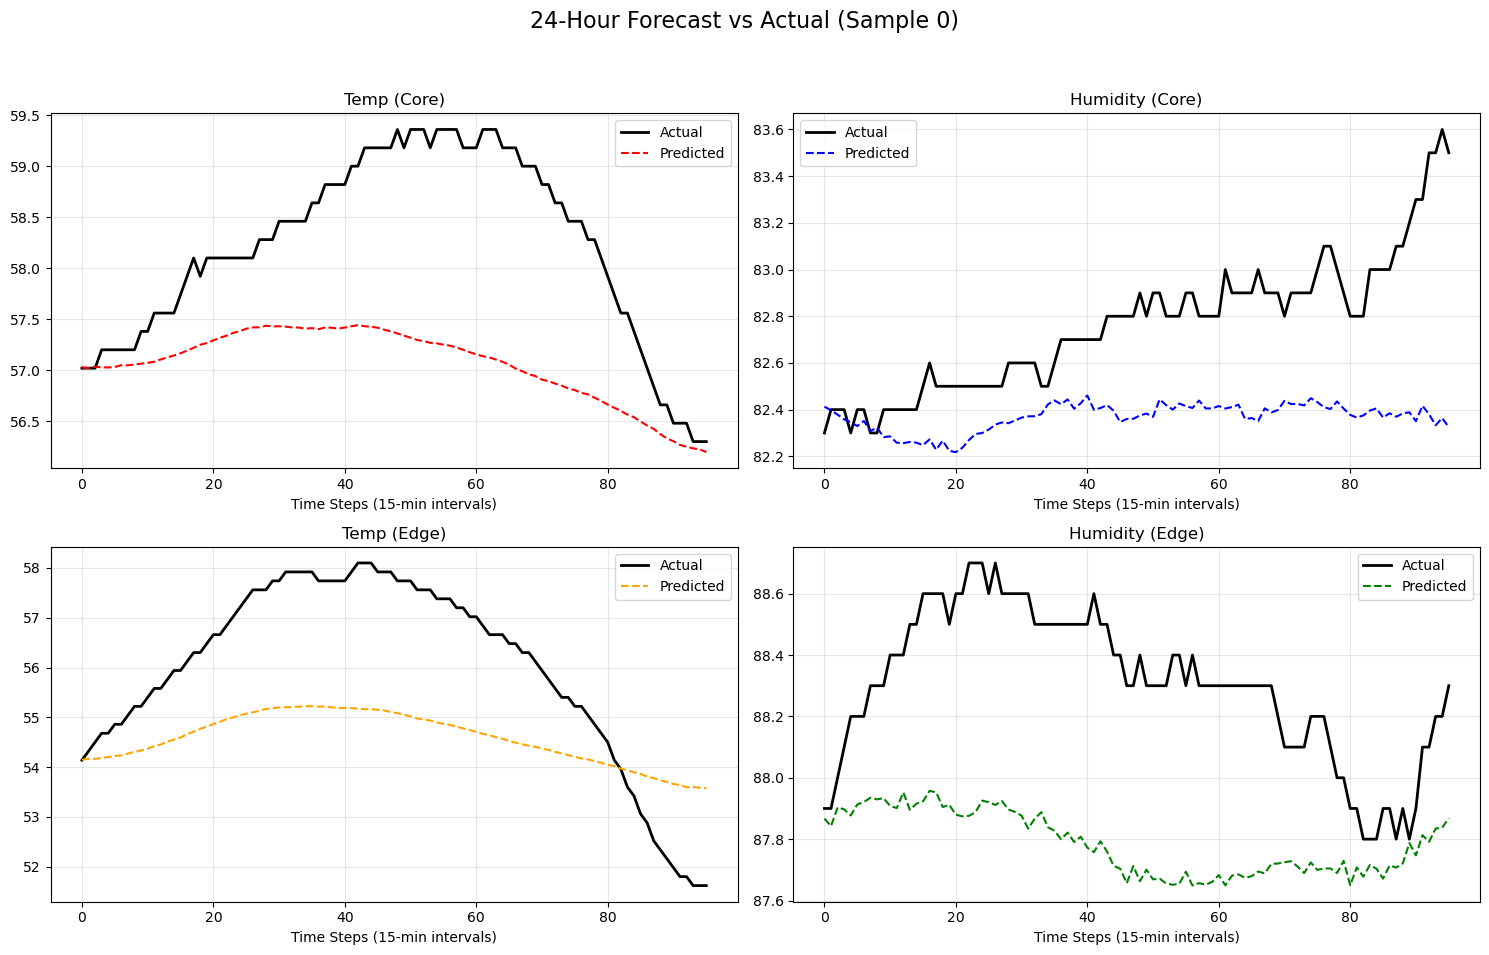

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load everything back in
model = joblib.load('beehive_model.joblib')
scaler_X = joblib.load('scaler_X.joblib')
scaler_y = joblib.load('scaler_y.joblib')

# 2. Prepare a sample for prediction
# (Using X_test from your session or re-creating from the DF)
# For this example, let's assume you have X_test and y_test ready
# y_test_actual will be our "Ground Truth"
y_pred_scaled = model.predict(X_test)

# 3. Inverse Scale the results to get real units (F and %)
y_pred_rescaled = scaler_y.inverse_transform(y_pred_scaled)
y_actual_rescaled = scaler_y.inverse_transform(y_test)

# 4. Reshape for plotting
# Each row is 384 values (96 time steps * 4 features)
# We reshape to (96, 4) to easily access Temperature, Humidity, etc.
sample_idx = 0  # Change this to look at different windows
actual_sample = y_actual_rescaled[sample_idx].reshape(96, 4)
pred_sample = y_pred_rescaled[sample_idx].reshape(96, 4)

# 5. Plotting
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'24-Hour Forecast vs Actual (Sample {sample_idx})', fontsize=16)

target_names = ['Temp (Core)', 'Humidity (Core)', 'Temp (Edge)', 'Humidity (Edge)']
colors = ['red', 'blue', 'orange', 'green']

for i, ax in enumerate(axes.flatten()):
    ax.plot(actual_sample[:, i], label='Actual', color='black', lw=2)
    ax.plot(pred_sample[:, i], label='Predicted', color=colors[i], linestyle='--')
    ax.set_title(target_names[i])
    ax.set_xlabel('Time Steps (15-min intervals)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()